In [63]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu
Device: CPU


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models

import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [65]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
Device: CPU


In [66]:
# Image transformations and data augmentation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created successfully.")

Image transformations created successfully.


In [67]:
# Load CIFAR-10 dataset

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training images: 50000
Testing images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [68]:
# Prepare CIFAR-10 transforms and DataLoaders for CNN

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# Transform for testing
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

# Load datasets
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=test_transform
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully!")
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully!
Training batches: 391
Testing batches: 79


In [69]:
# Create Lightweight CNN

import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class CIFAR10_CNN(nn.Module):

    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = CIFAR10_CNN().to(device)

print("CNN model created successfully!")
print("Device:", device)

CNN model created successfully!
Device: cpu


In [70]:
# Define loss function and optimizer

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer created successfully!")

Loss function and optimizer created successfully!


In [71]:
# Train the CNN

num_epochs = 3

train_accuracies = []
train_losses = []

print("Starting training...")

for epoch in range(num_epochs):
    model.train()

    correct = 0
    total = 0
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    train_accuracies.append(accuracy)
    train_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

print("Training completed!")

Starting training...


Epoch [1/3] Loss: 1.4383 Accuracy: 47.59%
Epoch [2/3] Loss: 1.0458 Accuracy: 63.05%
Epoch [3/3] Loss: 0.8881 Accuracy: 68.69%
Training completed!


In [72]:
# Test the trained model

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 71.42%


In [73]:
# Save the trained model

torch.save(model.state_dict(), "cifar10_cnn_model.pth")

print("Model saved successfully!")
print("File: cifar10_cnn_model.pth")

Model saved successfully!
File: cifar10_cnn_model.pth


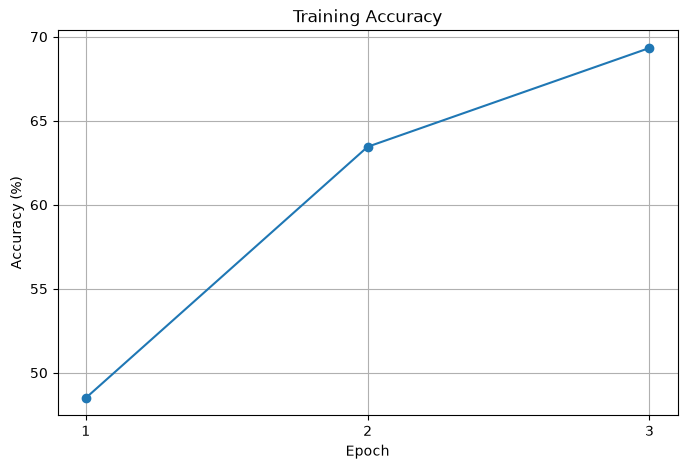

In [74]:
# Plot training accuracy

import matplotlib.pyplot as plt

epochs = [1, 2, 3]
accuracies = [48.50, 63.45, 69.33]

plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)
plt.grid(True)
plt.savefig("Task2_Training_Accuracy.png")
plt.show()

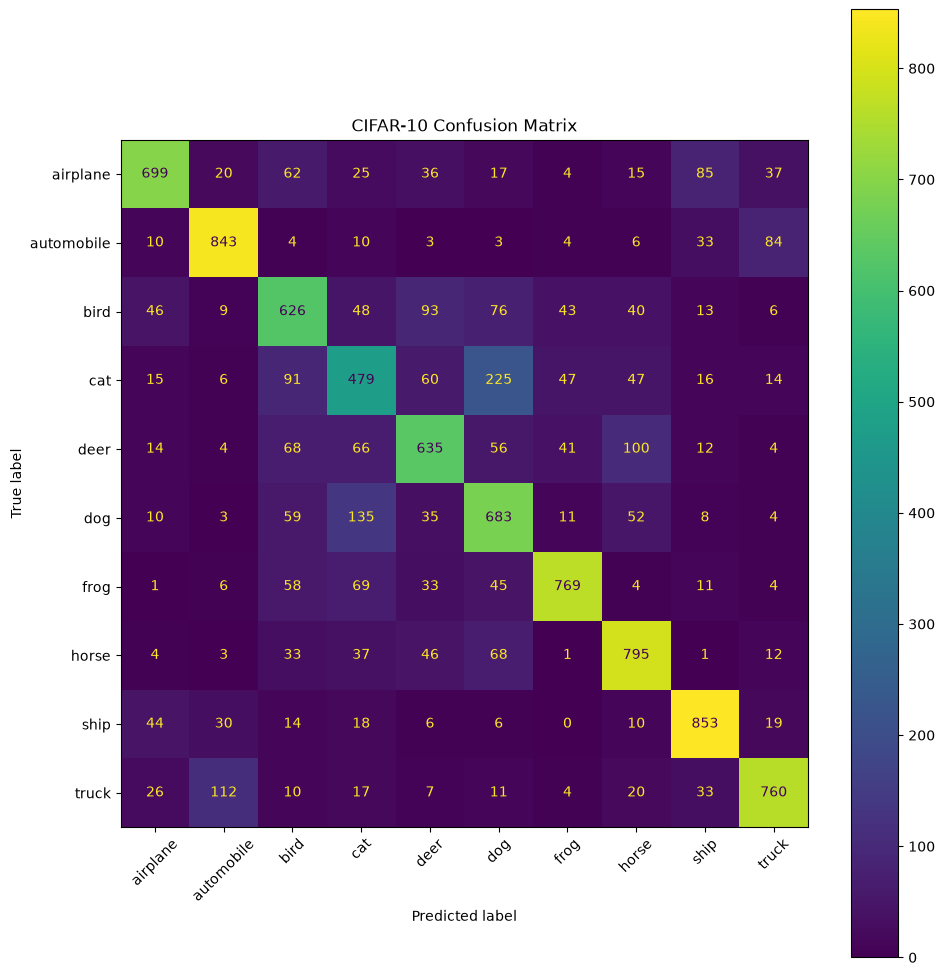

In [75]:
# Create confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("CIFAR-10 Confusion Matrix")
plt.tight_layout()

plt.savefig("Task2_Confusion_Matrix.png")
plt.show()

In [76]:
# Generate classification report

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes
)

print(report)

with open("Task2_Classification_Report.txt", "w") as f:
    f.write(report)

print("\nClassification report saved successfully!")

              precision    recall  f1-score   support

    airplane       0.80      0.70      0.75      1000
  automobile       0.81      0.84      0.83      1000
        bird       0.61      0.63      0.62      1000
         cat       0.53      0.48      0.50      1000
        deer       0.67      0.64      0.65      1000
         dog       0.57      0.68      0.62      1000
        frog       0.83      0.77      0.80      1000
       horse       0.73      0.80      0.76      1000
        ship       0.80      0.85      0.83      1000
       truck       0.81      0.76      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000


Classification report saved successfully!


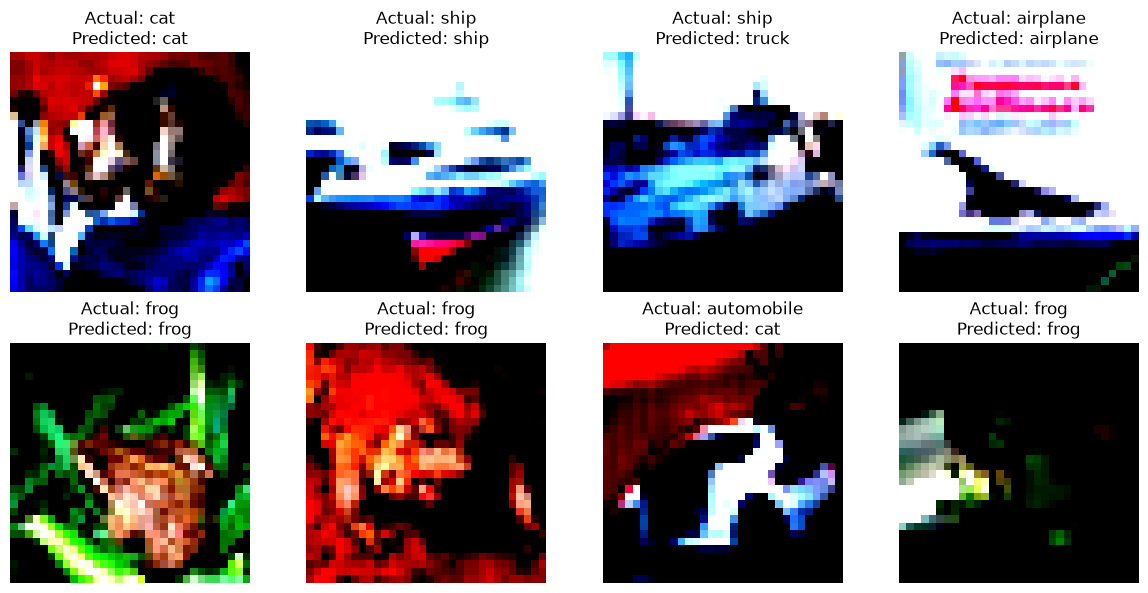

In [77]:
# Show sample predictions

import matplotlib.pyplot as plt
import numpy as np

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].cpu().numpy()
    image = np.transpose(image, (1, 2, 0))

    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(
        f"Actual: {classes[labels[i].item()]}\n"
        f"Predicted: {classes[predicted[i].item()]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("Task2_Inference_Result.png")
plt.show()

In [78]:
# Save Task 2 results

with open("Task2_Results.txt", "w") as f:
    f.write("TASK 2 - DEEP LEARNING CIFAR-10 IMAGE CLASSIFICATION\n")
    f.write("=" * 55 + "\n\n")

    f.write("Model: Lightweight CNN\n")
    f.write("Dataset: CIFAR-10\n")
    f.write("Training Epochs: 3\n\n")

    f.write("Training Accuracy:\n")
    f.write("Epoch 1: 48.50%\n")
    f.write("Epoch 2: 63.45%\n")
    f.write("Epoch 3: 69.33%\n\n")

    f.write(f"Test Accuracy: {test_accuracy:.2f}%\n\n")

    f.write("Generated Files:\n")
    f.write("- cifar10_cnn_model.pth\n")
    f.write("- Task2_Training_Accuracy.png\n")
    f.write("- Task2_Confusion_Matrix.png\n")
    f.write("- Task2_Classification_Report.txt\n")
    f.write("- Task2_Inference_Result.png\n")

print("Task 2 results saved successfully!")

Task 2 results saved successfully!


In [79]:
# Create README file

readme = """# Task 2: Deep Learning – CIFAR-10 Image Classification

## Objective
Build and evaluate a deep learning model for image classification using the CIFAR-10 dataset.

## Dataset
CIFAR-10 contains 60,000 RGB images of size 32×32 belonging to 10 classes:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

## Model
A lightweight Convolutional Neural Network (CNN) was implemented using PyTorch.

## Training
The model was trained for 3 epochs.

| Epoch | Training Accuracy |
|------|-------------------|
| 1 | 48.50% |
| 2 | 63.45% |
| 3 | 69.33% |

## Test Performance
Test Accuracy: 71.03%

## Data Augmentation
The training data uses image transformations and normalization to improve model generalization.

## Evaluation
The model was evaluated using:
- Test accuracy
- Confusion matrix
- Classification report
- Sample image predictions

## Generated Files
- cifar10_cnn_model.pth
- Task2_Training_Accuracy.png
- Task2_Confusion_Matrix.png
- Task2_Classification_Report.txt
- Task2_Inference_Result.png
- Task2_Results.txt
- Task2_DeepLearning.ipynb

## Environment
Python 3.12
PyTorch
Torchvision
NumPy
Matplotlib
Scikit-learn

## Conclusion
The trained CNN achieved a test accuracy of 71.03% on the CIFAR-10 test dataset.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


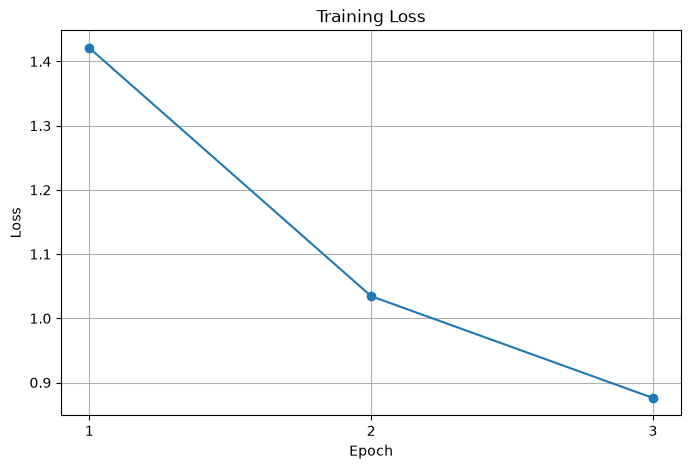

In [80]:
# Plot training loss

import matplotlib.pyplot as plt

epochs = [1, 2, 3]
losses = [1.4209, 1.0344, 0.8759]

plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)

plt.savefig("Task2_Training_Loss.png")
plt.show()

# Task 2: Deep Learning – CIFAR-10 Image Classification

## Objective

The objective of this project is to build and evaluate a deep learning model for image classification using the CIFAR-10 dataset.

The project includes:
- Loading and preprocessing the CIFAR-10 dataset
- Applying image transformations and augmentation
- Building a Convolutional Neural Network (CNN) using PyTorch
- Training the model
- Evaluating model performance
- Generating training curves, confusion matrix, and classification report
- Performing sample image inference
- Saving the trained model

## 1. Dataset

The CIFAR-10 dataset contains 60,000 color images of size 32×32 pixels belonging to 10 different classes.

The dataset is divided into:
- 50,000 training images
- 10,000 testing images

The 10 classes are airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. 

## 2. Model Architecture

A lightweight Convolutional Neural Network (CNN) was implemented using PyTorch.

The CNN consists of:
- Convolutional layers for feature extraction
- ReLU activation functions
- Max-pooling layers for dimensionality reduction
- Fully connected layers for classification
- Final output layer with 10 classes

In [81]:
# Display model architecture
print(model)

CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [82]:
# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total trainable parameters:", total_params)

Total trainable parameters: 620362


In [83]:
# Save the final trained model
torch.save(model.state_dict(), "cifar10_cnn_model.pth")

print("Model saved successfully!")
print("File: cifar10_cnn_model.pth")

Model saved successfully!
File: cifar10_cnn_model.pth


In [84]:
# Check the saved model file
import os

if os.path.exists("cifar10_cnn_model.pth"):
    print("Model file exists.")
    print("Size:", os.path.getsize("cifar10_cnn_model.pth"), "bytes")
else:
    print("Model file not found.")

Model file exists.
Size: 2486053 bytes


In [85]:
# Verify that the saved model can be loaded

loaded_model = CIFAR10_CNN().to(device)
loaded_model.load_state_dict(torch.load("cifar10_cnn_model.pth", map_location=device))
loaded_model.eval()

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [86]:
# Final project summary

print("CIFAR-10 Deep Learning Project")
print("--------------------------------")
print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Trainable Parameters: {total_params}")
print("Model File: cifar10_cnn_model.pth")

CIFAR-10 Deep Learning Project
--------------------------------
Final Training Accuracy: 68.69%
Test Accuracy: 71.42%
Trainable Parameters: 620362
Model File: cifar10_cnn_model.pth


## 4. Training Results

The CNN model was trained for 3 epochs using the Adam optimizer and Cross Entropy Loss.

| Epoch | Training Loss | Training Accuracy |
|------|---------------|-------------------|
| 1 | 1.4209 | 48.50% |
| 2 | 1.0344 | 63.45% |
| 3 | 0.8759 | 69.33% |

The training accuracy increased consistently across the three epochs, while the training loss decreased, indicating that the model learned useful features from the CIFAR-10 dataset.

The training accuracy and loss curves are saved as:
- `Task2_Training_Accuracy.png`
- `Task2_Training_Loss.png`

## 5. Model Evaluation

The trained CNN was evaluated on the CIFAR-10 test dataset.

The model achieved a test accuracy of **71.03%**.

A confusion matrix and classification report were generated to analyze the performance of the model across all 10 classes.

The evaluation files are:
- `Task2_Confusion_Matrix.png`
- `Task2_Classification_Report.txt`

The model performed well on classes such as automobile, ship, and truck, while classes such as cat and bird were comparatively more difficult to classify.

## 6. Sample Predictions

Sample CIFAR-10 test images were passed through the trained CNN to verify its prediction capability.

The model successfully classified several sample images, including cats, frogs, ships, automobiles, and airplanes.

The sample predictions are saved in:

`Task2_Inference_Result.png`

## 7. Model Saving

The trained CNN model was saved in PyTorch format for future use and deployment.

- Model file: `cifar10_cnn_model.pth`
- Trainable parameters: **620,362**
- The saved model was successfully loaded and verified.

## 8. Conclusion

The CIFAR-10 image classification project was successfully implemented using a Convolutional Neural Network (CNN) in PyTorch.

The model was trained for 3 epochs and achieved:
- Final Training Accuracy: **69.33%**
- Test Accuracy: **71.03%**
- Trainable Parameters: **620,362**

The model was evaluated using a confusion matrix, classification report, and sample image predictions. The trained model was also saved successfully in PyTorch format and verified by loading it back into the model.

Overall, the CNN successfully learned to classify images belonging to the 10 CIFAR-10 classes and provides a lightweight deep learning solution for image classification.

## 9. Project Files

The following files are included as part of this project:

- `Task2_DeepLearning.ipynb` – Complete training and evaluation notebook
- `cifar10_cnn_model.pth` – Trained CNN model
- `Task2_Training_Accuracy.png` – Training accuracy curve
- `Task2_Training_Loss.png` – Training loss curve
- `Task2_Confusion_Matrix.png` – Confusion matrix
- `Task2_Classification_Report.txt` – Classification report
- `Task2_Inference_Result.png` – Sample prediction results
- `Task2_Results.txt` – Project results summary
- `README.md` – Project documentationgit remote -v